In [ ]:
import cv2
import dlib

def Video_Capture(video_path, second, number):

    # Face detector
    detector = dlib.get_frontal_face_detector()

    # Import video and count frame
    video = cv2.VideoCapture(video_path)
    frame_num = 0

    # Infinite repetition sentence
    while True:
        ret, frame = video.read()

        if not ret:   # If the image doesn't read, break
            break

        if frame_num % second  == 0: 
            img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # Change the image to black and white
            rects = detector(img, 1)

            for i, rect in enumerate(rects):  
                # Create a face detection rectangle
                l = rect.left()
                t = rect.top()
                b = rect.bottom()
                r = rect.right()
                cv2.rectangle(frame, (l, t), (r, b), (0, 255, 0), 2)
                face_roi = img[t:b, l:r]
                # Skip to next picture when image size is 0
                if face_roi.size > 0:
                    cropped_image = cv2.resize(face_roi, (255, 255))  # Cut as many images as the retangle generated
                    # Save image
                    image_path = f"./face_data_org/{number}/{number}_{frame_num}.jpg"
                    cv2.imwrite(image_path, cropped_image)
        frame_num += 1

    video.release()

In [63]:
import os
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import torch
import matplotlib.pyplot as plt
import random
from torch import nn, optim
import dlib


class Face_Dataset(Dataset):
    def __init__(self, folder_dir, transform,ratio_train,ds_type):
        self.folder_dir = folder_dir
        self.folder_list = os.listdir(folder_dir)
        self.files_list = os.listdir(f'./face_data_org/{self.folder_list[0]}') + os.listdir(f'./face_data_org/{self.folder_list[1]}')+os.listdir(f'./face_data_org/{self.folder_list[2]}')+os.listdir(f'./face_data_org/{self.folder_list[3]}')+os.listdir(f'./face_data_org/{self.folder_list[4]}')
        random.shuffle(self.files_list)
        self.transform = transform
        self.ratio_train = ratio_train
        self.ds_type = ds_type
        
        self.num_train = int(self.ratio_train * len(self.files_list))
        self.num_test = len(self.files_list) - self.num_train
        
        if self.ds_type == 'train':
            self.files_list = self.files_list[:self.num_train]
        elif self.ds_type == 'test':
            self.files_list = self.files_list[self.num_train:]

    def __getitem__(self, index):
        image_name = self.files_list[index]
        self.files_dir = f'./face_data_org/{image_name[:1]}/'

        image_path = os.path.join(self.files_dir, self.files_list[index])
        
        input = Image.open(image_path)
        input = self.transform(input)
        target = int(image_name[:1])
        return input,target

    def __len__(self):
        if self.ds_type == 'train':
            return self.num_train
        
        elif self.ds_type == 'test':
            return self.num_test
        

In [87]:
folder_dir = f'./face_data_org/'
input_size = 250*250
batch_size = 32
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

In [88]:
ds_train = Face_Dataset(folder_dir=folder_dir,transform=transform,ratio_train=0.7,ds_type='train')
ds_test =Face_Dataset(folder_dir=folder_dir,transform=transform,ratio_train=0.7,ds_type='test')

dl_train = torch.utils.data.DataLoader(dataset = ds_train,batch_size=batch_size,shuffle = True,drop_last=True)
dl_test = torch.utils.data.DataLoader(dataset = ds_test,batch_size=batch_size,shuffle = True,drop_last=True)

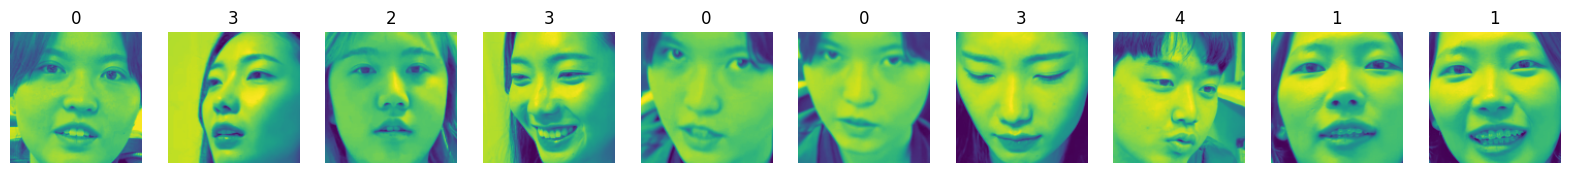

In [89]:
import matplotlib.pyplot as plt
import numpy as np

name = ['0', '1', '2', '3', '4']

fig, axs = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    img = ds_train[i][0].numpy()  # 텐서를 넘파이 배열로 변환
    label = ds_train[i][1]
    
    img = np.transpose(img, (1, 2, 0))  # 축 변경 (채널, 높이, 너비) -> (높이, 너비, 채널)
    img = (img - img.min()) / (img.max() - img.min())  # 정규화
    
    axs[i].imshow(img)  
    axs[i].set_title(name[label])
    axs[i].axis('off')
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BalancedCNN(torch.nn.Module):
    def __init__(self):
        super(BalancedCNN, self).__init__()
        # 드롭아웃 확률을 적절히 높여 규제 강화 (기존 0.5에서 0.4로 낮춤)
        self.keep_prob = 0.2

        self.layers = torch.nn.Sequential(
            # Convolutional Layer 1: 채널 수 32 -> 24로 감소
            torch.nn.Conv2d(1, 64, kernel_size=2, padding=3),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            
            # Convolutional Layer 2: 채널 수 128 -> 96으로 감소
            torch.nn.Conv2d(64, 128, kernel_size=3),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Flatten layer
            torch.nn.Flatten(),
            
            # Fully Connected Layer 1: 뉴런 수 감소
            # 입력 이미지 128x128 가정 시 최종 특성 맵 크기: 96 * 32 * 32 = 98304
            torch.nn.Linear(128*32*32, 64, bias=True),
            torch.nn.BatchNorm1d(64),
            torch.nn.ReLU(),
            # 드롭아웃 확률 p=0.6으로 설정
            torch.nn.Dropout(p=1 - self.keep_prob),
            
            # Fully Connected Layer 2
            torch.nn.Linear(64, 5, bias=True),
            torch.nn.Softmax(dim=1)
        )
        self._initialize_weights()

    def forward(self, x):
        out = self.layers(x)
        return out
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

# GPU 사용 가능 여부 확인 후 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# 수정된 모델을 GPU로 옮기기
model = BalancedCNN().to(device)

사용 중인 디바이스: cuda


In [111]:
import torch
import time

# 모델 학습에 필요한 하이퍼파라미터 설정
learning_rate = 0.001
num_epochs = 30

start = time.time()
# 옵티마이저, 손실 함수 및 장치 설정
opt = optim.SGD(model.parameters(), lr=3e-3, momentum=0.9)
loss_criterion = torch.nn.CrossEntropyLoss()
device = torch.device("cuda")

# 모델 평가 함수 정의

# 학습 및 평가 루프
losses = []
acces = []

for epoch in range(num_epochs):
    model.train()  # 학습 모드로 설정
    loss_avg = 0
    corrects = 0
    
    torch.cuda.empty_cache()
    for imgs, targets in dl_train:
        imgs, targets = imgs.to(device), targets.to(device)
        # print(targets.shape)
        imgs = imgs.to(torch.float)
        # imgs = imgs[:, 0, :,:].unsqueeze(0)
        output = model(imgs)
        # preds = F.softmax(output,dim=1)
        # print(preds.shape)
        preds = torch.argmax(output, dim=1)
        # preds = (output >= 0.5).float()
        loss = loss_criterion(output, targets)
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        loss_avg += loss.item()
        corrects += (targets == preds).sum().item()
        # ⭐ 중요한 부분: 연산 후 텐서들을 명시적으로 삭제
        del imgs, targets, output, preds, loss
        
        # ⭐ GPU 캐시 메모리 정리
        torch.cuda.empty_cache()
        
    loss_avg = loss_avg / len(dl_train)
    losses.append(loss_avg)
    acc = corrects / len(dl_train.dataset)
    acces.append(acc)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}; Test Accuracy: {acc:.4%}')
        # print(out)


    print(f"Epoch {epoch + 1}; Loss: {loss_avg:.4f}")
print("time:",time.time() - start)

Epoch 1; Loss: 1.2170
Epoch 2; Loss: 1.0515
Epoch 3; Loss: 1.0269
Epoch 4; Loss: 1.0083
Epoch 5; Loss: 1.0010
Epoch 6; Loss: 0.9919
Epoch 7; Loss: 0.9826
Epoch 8; Loss: 0.9814
Epoch 9; Loss: 0.9786
Epoch 10; Test Accuracy: 95.6571%
Epoch 10; Loss: 0.9765
Epoch 11; Loss: 0.9717
Epoch 12; Loss: 0.9640
Epoch 13; Loss: 0.9704
Epoch 14; Loss: 0.9643
Epoch 15; Loss: 0.9678
Epoch 16; Loss: 0.9633
Epoch 17; Loss: 0.9607
Epoch 18; Loss: 0.9598
Epoch 19; Loss: 0.9609
Epoch 20; Test Accuracy: 96.7714%
Epoch 20; Loss: 0.9579
Epoch 21; Loss: 0.9614
Epoch 22; Loss: 0.9583
Epoch 23; Loss: 0.9554
Epoch 24; Loss: 0.9536
Epoch 25; Loss: 0.9567
Epoch 26; Loss: 0.9537
Epoch 27; Loss: 0.9523
Epoch 28; Loss: 0.9495
Epoch 29; Loss: 0.9491
Epoch 30; Test Accuracy: 97.0000%
Epoch 30; Loss: 0.9497
time: 575.3123874664307


In [117]:
model.eval()  # 평가 모드로 설정
corrects = 0
errors = 0
threshold = 0.4

with torch.no_grad():  # 그라디언트 계산 비활성화 -> 메모리 사용량을 줄이고 연산 속도를 높이기 위함 (gradient 사용 안할 때 효율을 높이기 위해 사용)
    for imgs, targets in dl_test:
        imgs, targets = imgs.to(device), targets.to(device)  # CPU로 텐서를 이동시킴
        imgs = imgs.to(torch.float)  # 이미지를 float 형식으로 변환
        out = model(imgs)   # 모델로 예측

        probabilities = torch.softmax(out, dim=1)
        preds = (probabilities >= threshold).int().argmax(dim=1)
        corrects += (targets == preds).sum().item()  # 정확하게 예측된 수 계산
        errors += len(targets) - (targets == preds).sum().item() # 잘못 예측된 수 계산


acc = corrects / len(dl_test.dataset) # 정확도 계산
print(f'Final Test Accuracy: {acc:.4%},  Final Errors: {errors}')

Final Test Accuracy: 97.8667%,  Final Errors: 4


In [127]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

# 모델 평가 함수 (이전 답변에서 제공된 수정된 코드)
def get_clf_eval(y_test, pred):
    y_test_np = y_test.cpu().numpy()
    pred_np = pred.cpu().numpy()
    
    confusion = confusion_matrix(y_test_np, pred_np)
    accuracy = accuracy_score(y_test_np, pred_np)
    precision = precision_score(y_test_np, pred_np, average='micro')
    
    return accuracy, precision, confusion

# --- 모델 평가 루프 ---

model.eval() # 모델을 평가 모드로 전환
all_preds = []
all_targets = []

# DataLoader를 사용하여 테스트 데이터셋을 순회
with torch.no_grad(): # 기울기 계산 비활성화 (메모리 절약)
    for imgs, targets in dl_test:
        imgs, targets = imgs.to(device), targets.to(device)  # CPU로 텐서를 이동시킴
        imgs = imgs.to(torch.float)  # 이미지를 float 형식으로 변환
        out = model(imgs)   # 모델로 예측

        probabilities = torch.softmax(out, dim=1)
        preds = (probabilities >= threshold).int().argmax(dim=1)
        
        # 배치별 예측값과 실제값을 리스트에 추가
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 전체 데이터에 대한 평가
total_confusion = confusion_matrix(all_targets, all_preds)
total_accuracy = accuracy_score(all_targets, all_preds)
total_precision = precision_score(all_targets, all_preds, average='micro')

print(f"전체 데이터셋 Accuracy: {total_accuracy:.4f}")
print(f"전체 데이터셋 Precision: {total_precision:.4f}")
print("전체 데이터셋 Confusion Matrix:")
print(total_confusion)

전체 데이터셋 Accuracy: 0.9980
전체 데이터셋 Precision: 0.9980
전체 데이터셋 Confusion Matrix:
[[291   0   0   0   0]
 [  0 287   0   0   0]
 [  0   0 284   0   0]
 [  1   0   0 294   0]
 [  2   0   0   0 313]]


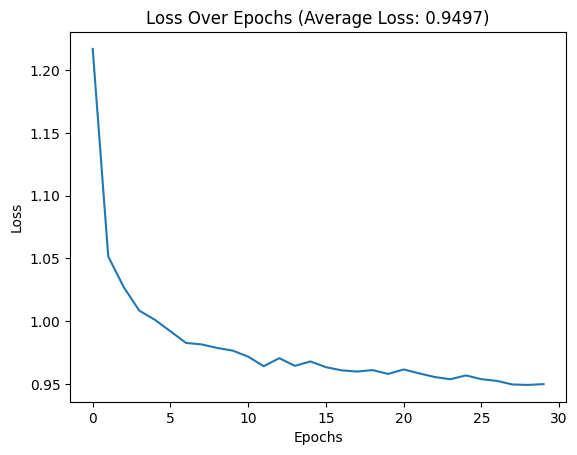

In [128]:
# 손실 그래프 그리기
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Loss Over Epochs (Average Loss: {loss_avg:.4f})")
plt.show()

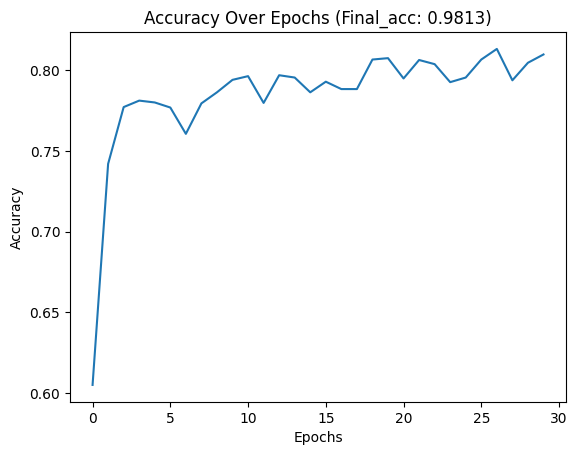

In [ ]:
plt.plot(acces)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Accuracy Over Epochs (Final_acc: {acc:.4f})")
plt.show()

In [ ]:
import torch

# 모델 전체를 저장하는 코드
torch.save(model, 'O.ver_model.pth')

# 저장된 모델을 불러오는 코드
model = torch.load('O.ver_model.pth')

C:\Users\PC\AppData\Local\Temp\ipykernel_11784\380584753.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('O.ver_model.pth')
